In [1]:
import os
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from tqdm import tqdm
from googletrans import Translator

import torch
from torch.utils.data import Dataset

# Import T5 model related modules from transformers
from transformers import T5ForConditionalGeneration, T5Tokenizer, TrainingArguments, Trainer, DataCollatorForSeq2Seq


In [2]:
# This is used to calculate the indicator, using the exact match accuracy
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    # 若 If -100 exists in labels, it is replaced by pad_token_id
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    exact_matches = [pred.strip() == label.strip() for pred, label in zip(decoded_preds, decoded_labels)]
    exact_match_accuracy = np.mean(exact_matches)
    return {"exact_match_accuracy": exact_match_accuracy}

import logging
logging.basicConfig(level=logging.INFO)

In [3]:
########################
# 1. Data preprocessing
########################

# Define data preprocessing functions and add cache functions
def load_and_preprocess(file_path, cache_file=None):
    # If a cache file is specified and exists, the cache data is loaded directly
    if cache_file is not None and os.path.exists(cache_file):
        print(f"Loading cached data from {cache_file} ...")
        df = pd.read_csv(cache_file)
        return df
    
    # Otherwise load the original data and process
    df = pd.read_csv(file_path)
    
    # Extracting HTML plain text using BeautifulSoup
    def extract_text(html_content):
        soup = BeautifulSoup(html_content, 'html.parser')
        return soup.get_text(separator=' ', strip=True)
    tqdm.pandas(desc="Extracting HTML Text")
    df['job_ad_details_clean'] = df['job_ad_details'].progress_apply(extract_text)
    
    # Translate text into English
    translator = Translator()
    def translate_text(text, dest='en'):
        try:
            translation = translator.translate(text, dest=dest)
            return translation.text
        except Exception as e:
            print(f"Translation error: {e}")
            return text
    tqdm.pandas(desc="Translating Text")
    df['job_ad_details_translated'] = df['job_ad_details_clean'].progress_apply(lambda x: translate_text(x, dest='en'))
    
    # Set the target text directly to y_true
    df['target'] = df['y_true'].astype(str).str.strip()
    
    # If a cache file is specified, the processing results will be written to the file and saved.
    if cache_file is not None:
        df.to_csv(cache_file, index=False)
        print(f"Processed data is saved to {cache_file}")
    
    return df

# Define the cache file path (here the processed training set and test set are stored in the data folder respectively)
train_cache_file = os.path.join("data", "processed_salary_train.csv")
test_cache_file = os.path.join("data", "processed_salary_test.csv")

# Load the training set and test set. If the cache file exists, load the cache data directly; otherwise, perform complete preprocessing
train_df = load_and_preprocess(os.path.join("data", "salary_labelled_development_set.csv"), cache_file=train_cache_file)
test_df = load_and_preprocess(os.path.join("data", "salary_labelled_test_set.csv"), cache_file=test_cache_file)

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

Loading cached data from data\processed_salary_train.csv ...
Loading cached data from data\processed_salary_test.csv ...
Train samples: 2267
Test samples: 567


In [4]:
########################
# 2. Constructing Dataset and Tokenization
########################
# Here we use T5 for text generation tasks
model_name = "t5-small"  
from transformers import T5Tokenizer, T5ForConditionalGeneration, DataCollatorForSeq2Seq
tokenizer = T5Tokenizer.from_pretrained(model_name)

# Load the model for subsequent generation and data collator
model = T5ForConditionalGeneration.from_pretrained(model_name)

class SalarySeq2SeqDataset(Dataset):
    def __init__(self, df, tokenizer, max_input_length=512, max_target_length=32):
        self.tokenizer = tokenizer
        # Input text: Translated ad content; Target text: Original y_true content
        self.input_texts = df['job_ad_details_translated'].tolist()
        self.target_texts = df['target'].tolist()
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length
        
    def __len__(self):
        return len(self.input_texts)
    
    def __getitem__(self, idx):
        input_text = self.input_texts[idx]
        target_text = self.target_texts[idx]
        input_encoding = self.tokenizer(
            input_text, 
            max_length=self.max_input_length, 
            truncation=True, 
            padding="max_length",
            return_tensors="pt"
        )
        target_encoding = self.tokenizer(
            target_text,
            max_length=self.max_target_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        return {
            "input_ids": input_encoding["input_ids"].squeeze(0),
            "attention_mask": input_encoding["attention_mask"].squeeze(0),
            "labels": target_encoding["input_ids"].squeeze(0)
        }

train_dataset = SalarySeq2SeqDataset(train_df, tokenizer)
test_dataset = SalarySeq2SeqDataset(test_df, tokenizer)
print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

# Data collator automatically handles dynamic padding
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Train dataset size: 2267
Test dataset size: 567


In [5]:
########################
# 3. Model training
########################
import random
from transformers import T5ForConditionalGeneration, Trainer, TrainingArguments, TrainerCallback

# Loading the T5 model
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Training parameters
training_args = TrainingArguments(
    output_dir="./results_salary_seq2seq",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    learning_rate=5e-5,
    logging_steps=100,
    save_total_limit=1
)

class PartialEvalCallback(TrainerCallback):
    def set_trainer(self, trainer):
        self.trainer = trainer
        return trainer

    def on_epoch_end(self, args, state, control, **kwargs):
        # Only take the first 100 items of the test set for quick verification (change to fewer or random sampling as needed)
        n_eval = min(100, len(test_df))
        indices = list(range(n_eval))
        
        model.eval()
        device = self.trainer.model.device
        matches = 0
        
        with torch.no_grad():
            for idx in indices:
                sample = test_dataset[idx]
                input_ids = sample["input_ids"].unsqueeze(0).to(device)
                attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
                # 生成
                gen_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=32)
                pred = tokenizer.decode(gen_ids[0], skip_special_tokens=True).strip()
                true = test_df.iloc[idx]["target"].strip()
                if pred == true:
                    matches += 1
        
        exact_match = matches / n_eval
        self.trainer.log({
            "epoch":       state.epoch,
            "eval_exact_match_accuracy": exact_match,
        })
        print(f"\n>>> Epoch {int(state.epoch)} Partial Eval on {n_eval} samples: Exact‑Match Accuracy = {exact_match:.4f}\n")
        model.train()
        return control

# Construct Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
    callbacks=[PartialEvalCallback()],
)

# Inject trainer reference into Callback
for cb in trainer.callback_handler.callbacks:
    if isinstance(cb, PartialEvalCallback):
        cb.trainer = trainer

print("=== Start Training ===")
train_result = trainer.train()
trainer.save_model()
print("=== Training Finished ===")

C:\Users\21943\AppData\Local\Temp\ipykernel_20620\1724676474.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


=== Start Training ===


C:\ProgramData\anaconda3\Lib\site-packages\transformers\data\data_collator.py:741: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss
100,4.533200
200,0.613800
300,0.270900
400,0.212800
500,0.181200
600,0.142100
700,0.140600
800,0.118800
900,0.109300
1000,0.108200



>>> Epoch 1 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7000


>>> Epoch 2 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7300


>>> Epoch 3 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7300


>>> Epoch 4 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7400


>>> Epoch 5 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7600


>>> Epoch 6 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7600


>>> Epoch 7 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7700


>>> Epoch 8 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7600


>>> Epoch 9 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7600


>>> Epoch 10 Partial Eval on 100 samples: Exact‑Match Accuracy = 0.7600

=== Training Finished ===


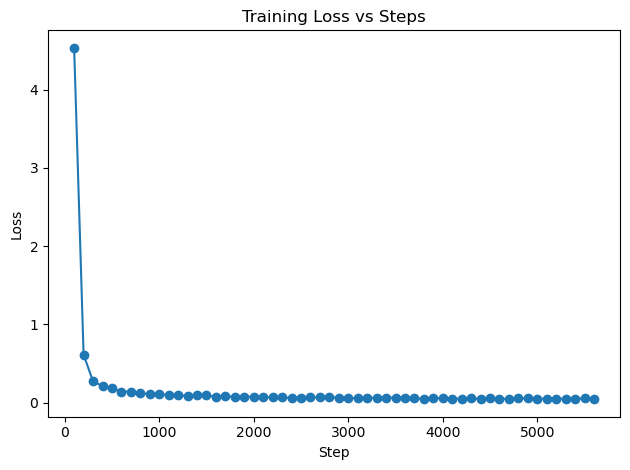

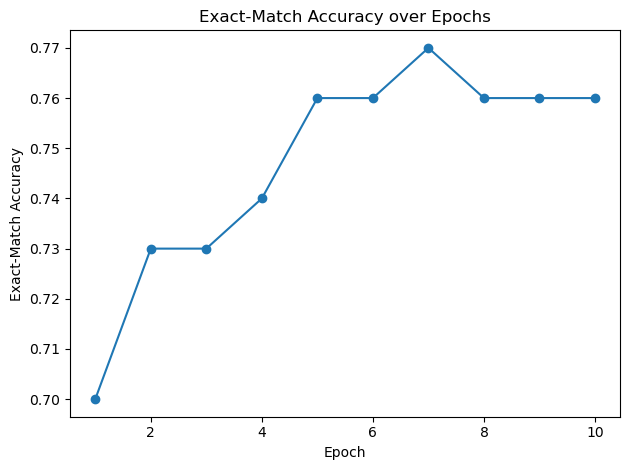

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'trainer' is in the current namespace (run this cell after model training)
if 'trainer' not in globals():
    raise RuntimeError("Trainer object not found. Please run this cell after training where 'trainer' is defined.")

# Extract training logs from the Trainer state
logs = trainer.state.log_history

# Filter for training loss entries (entries that contain 'loss' and 'step')
train_logs = [entry for entry in logs if 'loss' in entry and 'step' in entry]
df_train = pd.DataFrame(train_logs)

# Filter for evaluation entries (entries with 'eval_exact_match_accuracy')
eval_logs = [entry for entry in logs if 'eval_exact_match_accuracy' in entry]
df_eval = pd.DataFrame(eval_logs)

# Plot: Training Loss vs Steps
plt.figure()
plt.plot(df_train['step'], df_train['loss'], marker='o')
plt.title("Training Loss vs Steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

# Plot: Exact-Match Accuracy vs Epoch
plt.figure()
plt.plot(df_eval['epoch'], df_eval['eval_exact_match_accuracy'], marker='o')
plt.title("Exact-Match Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Exact-Match Accuracy")
plt.tight_layout()
plt.show()


In [7]:
########################
# 4. Test evaluation and output of some case results
########################
#Get the results for n cases on the test set: Output the preprocessed original ad, 
#the target salary string (y_true), and the salary level generated by the model
subset_indices = list(range(20))
print("\n=== Test case prediction results ===\n")
label_dict = {}  # The target text is directly output here

for idx in subset_indices:
    sample = test_dataset[idx]
    # Transfer input_ids and attention_mask to the device where the model is located
    input_ids = sample["input_ids"].unsqueeze(0).to(model.device)  
    attention_mask = sample["attention_mask"].unsqueeze(0).to(model.device)
    # Call generate to generate prediction results
    generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=32)
    generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()
    # Get the preprocessed ad text and target (y_true) from the original DataFrame
    ad_text = test_df.iloc[idx]["job_ad_details_translated"]
    true_salary = test_df.iloc[idx]["target"]
    
    print(f"sample {idx+1}:")
    print("Pre-processed original advertisement:")
    print(ad_text)
    print("Target marker (y_true):", true_salary)
    print("Model predicted tags:", generated_text)
    print("Match or not:", "Match" if generated_text == true_salary else "Not Match")
    print("-" * 80)


=== Test case prediction results ===

sample 1:
Pre-processed original advertisement:
Responsible as Cashier Managing all records of checks received Provide reports required by HQ (Account Department and Human Resources Department) Monthly stock count All other work prescribed by Branch Manager and Supervisor at any SPM / O Level / SKM Level 1 / SKM Level 2 / SKM Level 3010-3938581 Seng Li Marketing Sdn Bhd is a one-stop auto parts trading company Salary: RM 1500-1800
Target marker (y_true): 1500-1800-MYR-MONTHLY
Model predicted tags: 1500-1800-MYR-MONTHLY
Match or not: Match
--------------------------------------------------------------------------------
sample 2:
Pre-processed original advertisement:
No. : 35-24-0004254 LA Part-time Date: 01/02/2024 Position: School dispatched meal staff Company/employer name: Baili Food Group Co., Ltd. Region: Kuifang Industry: Other manufacturing Responsibilities: Responsible for distributing meals, cleaning garbage, pushing carts to deliver meals

Exact-Match Accuracy: 0.7319

    min_salary Accuracy: 0.8483
    max_salary Accuracy: 0.8219
      currency Accuracy: 0.9048
     frequency Accuracy: 0.9242

--- Classification Report for min_salary ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       238
       1,000       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         2
         100       1.00      1.00      1.00         7
        1000       0.00      0.00      0.00         1
       10000       0.00      0.00      0.00         0
      100000       0.00      0.00      0.00         1
      102051       1.00      1.00      1.00         1
         105       0.00      0.00      0.00         0
         106       0.00      0.00      0.00         1
         107       1.00      1.00      1.00         1
      108595       1.00      1.00      1.00         1
      110000       1.00      1.00      1.00         1
       11197       0.00      0.00      

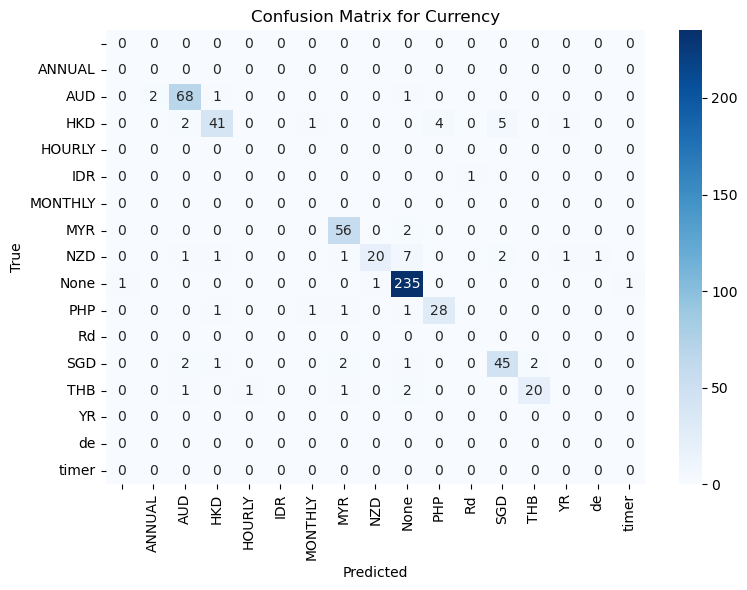

--- Classification Report for frequency ---
                 precision    recall  f1-score   support

                      0.00      0.00      0.00         0
         ANNUAL       0.92      0.85      0.88        26
          DAILY       0.73      0.79      0.76        14
         HOURLY       0.95      0.88      0.91       130
Jahresendehalt.       0.00      0.00      0.00         0
        MONTHLY       0.95      0.96      0.96       138
           None       0.94      0.98      0.96       238
         WEEKLY       0.91      0.48      0.62        21
       division       0.00      0.00      0.00         0

       accuracy                           0.92       567
      macro avg       0.60      0.55      0.57       567
   weighted avg       0.94      0.92      0.93       567



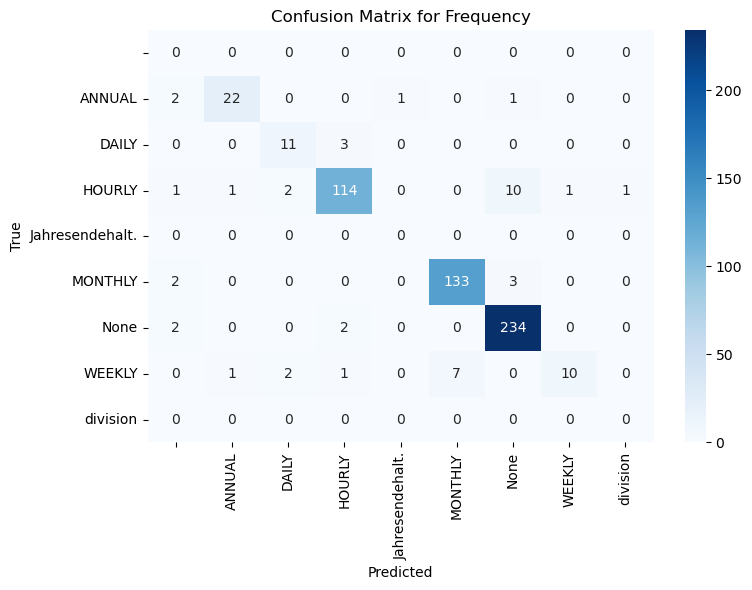

In [9]:
# %% [code]
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

device = model.device

# 1. Generate predictions on the test set
preds, trues = [], []
for i in range(len(test_dataset)):
    sample = test_dataset[i]
    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    gen_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=32)
    pred = tokenizer.decode(gen_ids[0], skip_special_tokens=True).strip()
    true = test_df.iloc[i]["target"].strip()
    preds.append(pred)
    trues.append(true)

# 2. Exact-Match Accuracy
exact_match = sum(p == t for p, t in zip(preds, trues)) / len(trues)
print(f"Exact-Match Accuracy: {exact_match:.4f}\n")

# 3. Slot-Level Accuracy
# Use rsplit to guard against extra '-' in salary ranges
true_slots = [t.rsplit("-", 3) for t in trues]
pred_slots = [p.rsplit("-", 3) for p in preds]

slot_names = ["min_salary", "max_salary", "currency", "frequency"]
for idx, name in enumerate(slot_names):
    y_true = [slots[idx] if len(slots) > idx else "" for slots in true_slots]
    y_pred = [slots[idx] if len(slots) > idx else "" for slots in pred_slots]
    acc = accuracy_score(y_true, y_pred)
    print(f"{name:>14} Accuracy: {acc:.4f}")
print()

# 4. Slot-Level Classification Reports (and confusion matrices for currency & frequency)
for idx, name in enumerate(slot_names):
    y_true = [slots[idx] if len(slots) > idx else "" for slots in true_slots]
    y_pred = [slots[idx] if len(slots) > idx else "" for slots in pred_slots]
    
    print(f"--- Classification Report for {name} ---")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    # Only show confusion matrix heatmap for currency & frequency
    if name in ("currency", "frequency"):
        labels = sorted(set(y_true) | set(y_pred))
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels, yticklabels=labels)
        plt.title(f"Confusion Matrix for {name.capitalize()}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()
    else:
        # for min_salary and max_salary, no confusion matrix
        pass